# WanderWise: Predicting Your Perfect Getaway  
## A Hybrid Travel Destination Recommender System

**Dataset:** Traveler Trip Dataset from Kaggle  
**Project Type:** Final Project for Recommender Systems / Data Science  
**Main Goal:** Recommend personalized travel destinations based on traveler demographics, trip details, budget, accommodation, transportation, and historical trip patterns.

---

## Executive Summary

WanderWise is a personalized travel recommendation engine that suggests destinations based on how well a destination fits a traveler's profile and trip preferences.

Because the dataset does not contain explicit user ratings, clicks, or satisfaction scores, this project uses a **hybrid recommender system** rather than pure collaborative filtering.

The model combines:

1. Traveler profile similarity  
2. Budget compatibility  
3. Trip duration compatibility  
4. Accommodation and transportation preference matching  
5. Destination popularity and confidence  

The final output is an interpretable ranked list of destinations with score components and recommendation comments.


# 1. Problem Statement

Travel planning can be difficult because travelers need to balance destination appeal with practical constraints such as budget, trip duration, accommodation, transportation, and personal profile.

This project answers the question:

> Given a traveler profile and desired trip preferences, which destinations are most suitable?

## Data Science Objective

Build a recommender system that ranks destinations using a hybrid recommendation score.

## Why Not Pure Collaborative Filtering?

Collaborative filtering usually needs user-item interactions such as ratings, likes, bookings, or clicks. Since this dataset contains historical trip details but no explicit ratings, WanderWise uses a hybrid approach based on content similarity, business rules, and popularity.


In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)


# 2. Load Dataset

The dataset contains historical trip records with destination, dates, traveler demographics, accommodation, and transportation details.


In [3]:
DATA_PATH = "/Users/wpmangapot/Desktop/WorkFolder/Projects/stat280_pml/notebooks/Project/Travel details dataset.csv"

df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)
display(df_raw.head())

Dataset shape: (139, 13)


,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200


In [4]:
# ============================================================
# DATA AUDIT
# ============================================================

data_audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "unique_count": df_raw.nunique()
}).sort_values("missing_pct", ascending=False)

display(data_audit)

,dtype,missing_count,missing_pct,unique_count
Transportation type,object,3,2.16,9
Transportation cost,object,3,2.16,48
Destination,object,2,1.44,59
Start date,object,2,1.44,111
End date,object,2,1.44,125
Duration (days),float64,2,1.44,9
Traveler name,object,2,1.44,109
Traveler age,float64,2,1.44,29
Traveler gender,object,2,1.44,2
Traveler nationality,object,2,1.44,41


## Data Audit Interpretation

The dataset is small but usable for a final project prototype. There are a few missing values in destination, date, duration, traveler, accommodation, and transportation fields. Since these fields are important for the recommender, the next step cleans and imputes the data.

The project treats the dataset as historical trip behavior. The goal is not to predict a numeric rating but to rank destinations based on profile fit and trip suitability.


In [5]:
# ============================================================
# DATA CLEANING FUNCTIONS
# ============================================================

def clean_column_names(dataframe):
    df = dataframe.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.strip("_")
    )
    return df


def clean_money(value):
    if pd.isna(value):
        return np.nan
    value = str(value)
    value = re.sub(r"[^0-9.]", "", value)
    if value == "":
        return np.nan
    return float(value)


def split_destination(value):
    if pd.isna(value):
        return pd.Series(["Unknown", "Unknown"])
    parts = [p.strip() for p in str(value).split(",")]
    if len(parts) >= 2:
        return pd.Series([parts[0], parts[-1]])
    return pd.Series([str(value).strip(), "Unknown"])


def normalize_text(value):
    if pd.isna(value):
        return "unknown"
    return str(value).strip().lower()


def mode_or_unknown(series):
    series = series.dropna()
    if len(series) == 0:
        return "Unknown"
    return series.mode().iloc[0]


def get_season(month):
    if pd.isna(month):
        return "Unknown"
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"


In [6]:
# ============================================================
# CLEAN DATASET
# ============================================================

df = clean_column_names(df_raw)

df["accommodation_cost_clean"] = df["accommodation_cost"].apply(clean_money)
df["transportation_cost_clean"] = df["transportation_cost"].apply(clean_money)

df[["destination_city", "destination_country"]] = df["destination"].apply(split_destination)

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce")

df["duration_days_clean"] = pd.to_numeric(df["duration_days"], errors="coerce")
df["traveler_age_clean"] = pd.to_numeric(df["traveler_age"], errors="coerce")

df["total_trip_cost"] = (
    df["accommodation_cost_clean"].fillna(0) +
    df["transportation_cost_clean"].fillna(0)
)
df.loc[df["total_trip_cost"] == 0, "total_trip_cost"] = np.nan

numeric_cols = [
    "duration_days_clean",
    "traveler_age_clean",
    "accommodation_cost_clean",
    "transportation_cost_clean",
    "total_trip_cost"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = [
    "destination",
    "traveler_gender",
    "traveler_nationality",
    "accommodation_type",
    "transportation_type",
    "destination_city",
    "destination_country"
]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown").astype(str).str.strip()

df["travel_month"] = df["start_date"].dt.month
df["travel_season"] = df["travel_month"].apply(get_season)

display(df.head())

,trip_id,destination,start_date,end_date,duration_days,traveler_name,traveler_age,traveler_gender,traveler_nationality,accommodation_type,accommodation_cost,transportation_type,transportation_cost,accommodation_cost_clean,transportation_cost_clean,destination_city,destination_country,duration_days_clean,traveler_age_clean,total_trip_cost,travel_month,travel_season
0,1,"London, UK",2023-05-01,2023-05-08,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600,1200.0,600.0,London,UK,7.0,35.0,1800.0,5.0,Spring
1,2,"Phuket, Thailand",2023-06-15,2023-06-20,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500,800.0,500.0,Phuket,Thailand,5.0,28.0,1300.0,6.0,Summer
2,3,"Bali, Indonesia",2023-07-01,2023-07-08,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700,1000.0,700.0,Bali,Indonesia,7.0,45.0,1700.0,7.0,Summer
3,4,"New York, USA",2023-08-15,2023-08-29,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000,2000.0,1000.0,New York,USA,14.0,29.0,3000.0,8.0,Summer
4,5,"Tokyo, Japan",2023-09-10,2023-09-17,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200,700.0,200.0,Tokyo,Japan,7.0,26.0,900.0,9.0,Fall



# 3. Exploratory Data Analysis

The EDA focuses on attributes that are useful for recommendation:

- Popular destinations
- Traveler age distribution
- Trip duration distribution
- Total trip cost distribution
- Accommodation and transportation patterns

,destination,trip_count
0,Paris,7
1,Bali,7
2,"Tokyo, Japan",7
3,"Paris, France",7
4,Tokyo,5
5,Sydney,5
6,Rome,5
7,New York,5
8,"Bali, Indonesia",5
9,"Rio de Janeiro, Brazil",4


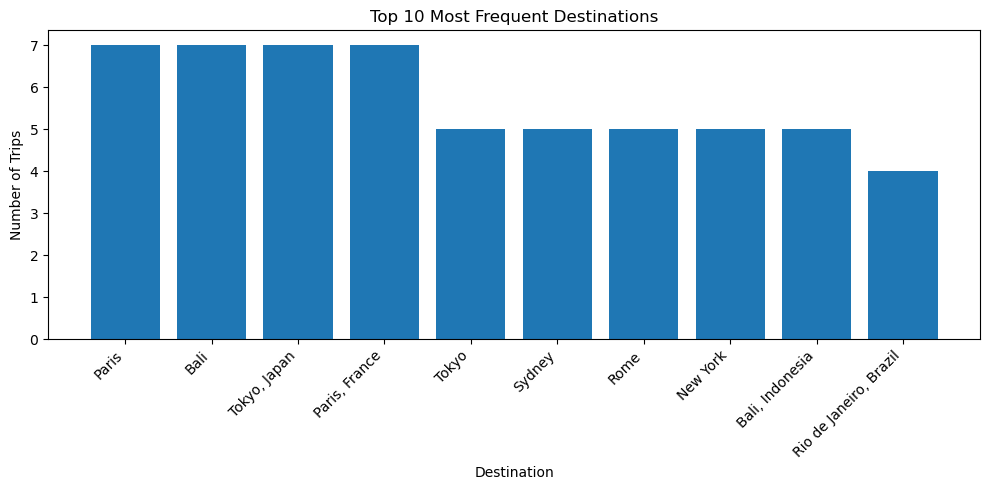

In [7]:
# ============================================================
# DESTINATION POPULARITY
# ============================================================

destination_counts = df["destination"].value_counts().reset_index()
destination_counts.columns = ["destination", "trip_count"]

display(destination_counts.head(10))

plt.figure(figsize=(10, 5))
plt.bar(destination_counts.head(10)["destination"], destination_counts.head(10)["trip_count"])
plt.title("Top 10 Most Frequent Destinations")
plt.xlabel("Destination")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Destination Popularity Interpretation

The most frequent destinations have the strongest historical support in the dataset. Popular destinations are useful because they provide more evidence about typical budget, duration, accommodation, and traveler profile.

However, popularity alone is not enough. A popular destination may still be inappropriate for a traveler if it does not match the user's budget, preferred duration, or travel style.


,traveler_age_clean,duration_days_clean,total_trip_cost
count,139.000000,139.000000,139.000000
mean,33.143885,7.597122,1878.597122
std,7.098235,1.591278,1821.829689
min,20.000000,5.000000,100.000000
25%,28.000000,7.000000,1000.000000
50%,31.000000,7.000000,1400.000000
75%,37.500000,8.000000,1900.000000
max,60.000000,14.000000,10500.000000


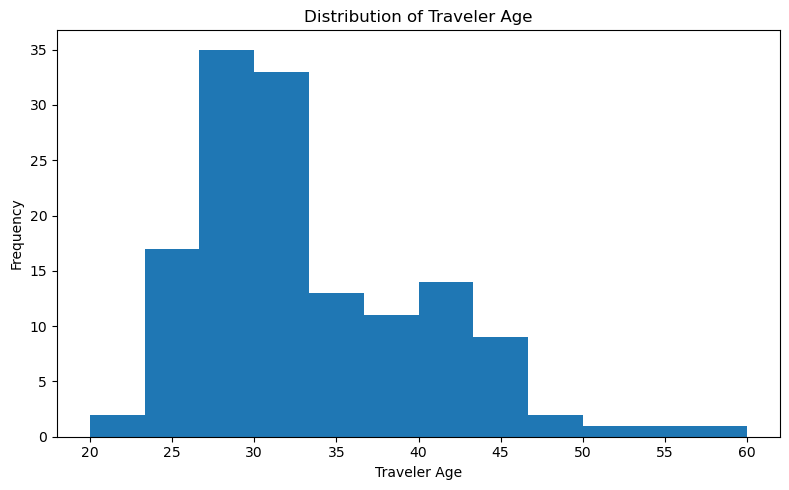

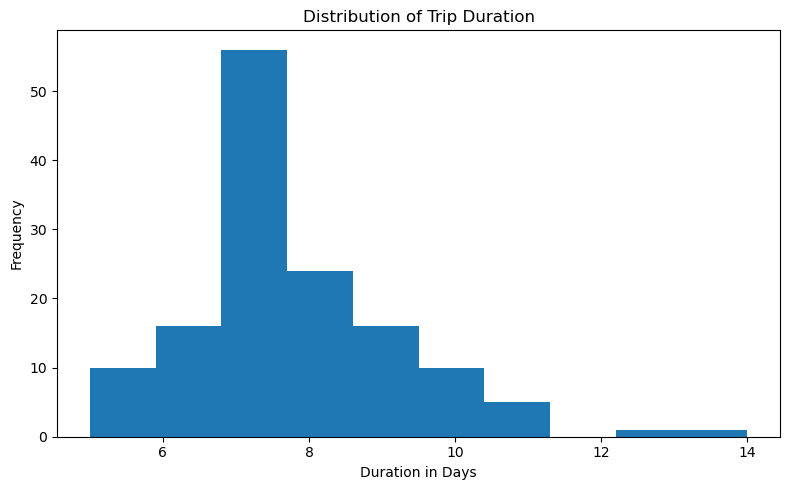

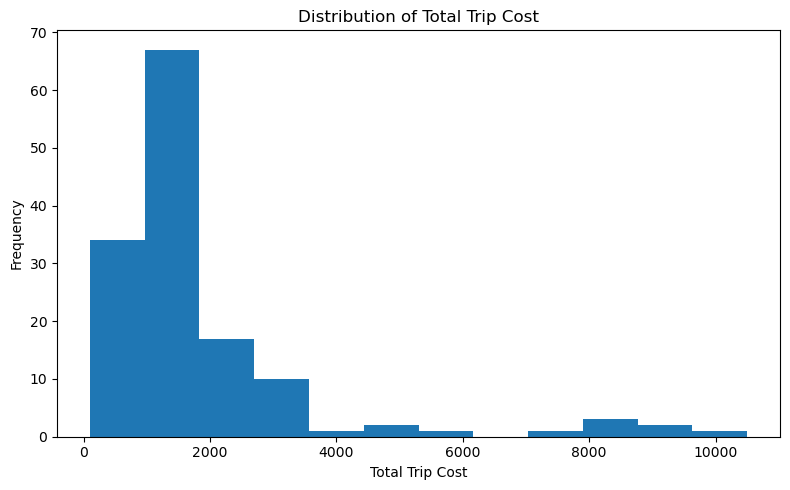

In [8]:
# ============================================================
# AGE, DURATION, AND COST DISTRIBUTIONS
# ============================================================

display(df[["traveler_age_clean", "duration_days_clean", "total_trip_cost"]].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["traveler_age_clean"], bins=12)
plt.title("Distribution of Traveler Age")
plt.xlabel("Traveler Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["duration_days_clean"], bins=10)
plt.title("Distribution of Trip Duration")
plt.xlabel("Duration in Days")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["total_trip_cost"], bins=12)
plt.title("Distribution of Total Trip Cost")
plt.xlabel("Total Trip Cost")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Age, Duration, and Cost Interpretation

Age gives a simple demographic signal for traveler similarity. Trip duration and total cost are more operationally important because they determine whether a recommendation is realistic.

A strong travel recommender should avoid suggesting destinations that are historically too expensive or require a very different trip length compared with the user's stated preferences.


,accommodation_type,count
0,Hotel,60
1,Airbnb,30
2,Hostel,24
3,Resort,14
4,Villa,4
5,Vacation rental,3
6,Unknown,2
7,Riad,1
8,Guesthouse,1


,transportation_type,count
0,Plane,57
1,Train,37
2,Flight,13
3,Car rental,13
4,Bus,6
5,Airplane,5
6,Unknown,3
7,Car,3
8,Subway,1
9,Ferry,1


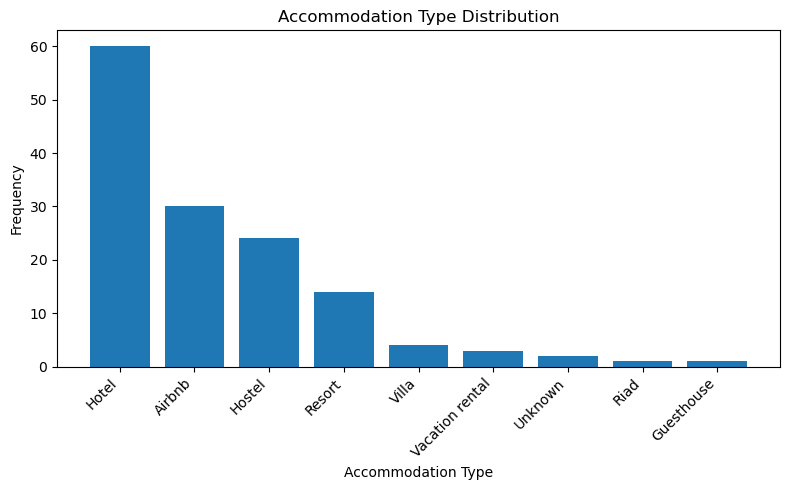

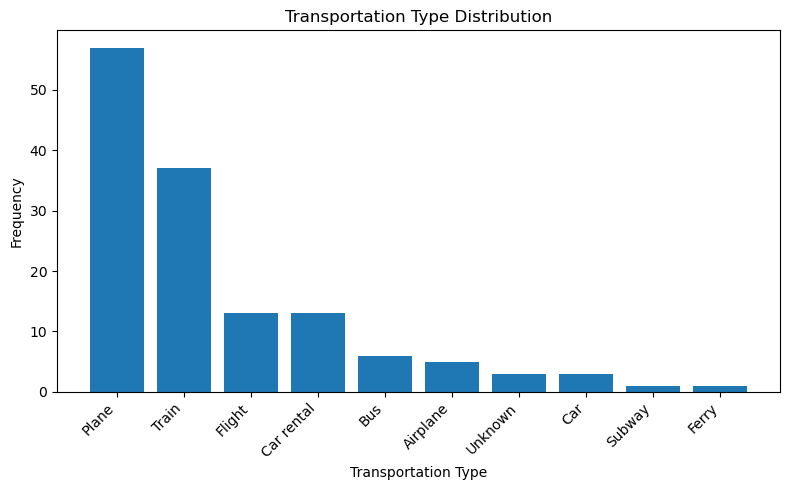

In [9]:
# ============================================================
# ACCOMMODATION AND TRANSPORTATION PATTERNS
# ============================================================

accommodation_counts = df["accommodation_type"].value_counts().reset_index()
accommodation_counts.columns = ["accommodation_type", "count"]
display(accommodation_counts)

transport_counts = df["transportation_type"].value_counts().reset_index()
transport_counts.columns = ["transportation_type", "count"]
display(transport_counts)

plt.figure(figsize=(8, 5))
plt.bar(accommodation_counts["accommodation_type"], accommodation_counts["count"])
plt.title("Accommodation Type Distribution")
plt.xlabel("Accommodation Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(transport_counts["transportation_type"], transport_counts["count"])
plt.title("Transportation Type Distribution")
plt.xlabel("Transportation Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



# 4. Destination Profile Engineering

Since the recommender ranks destinations, the trip-level dataset is aggregated into a destination-level profile table.

Each destination profile contains:

- Median traveler age
- Median trip duration
- Median total trip cost
- Common nationality
- Common accommodation type
- Common transportation type
- Common season
- Historical trip count


In [10]:
# ============================================================
# CREATE DESTINATION PROFILES
# ============================================================

destination_profiles = (
    df.groupby("destination")
    .agg(
        destination_city=("destination_city", mode_or_unknown),
        destination_country=("destination_country", mode_or_unknown),
        median_traveler_age=("traveler_age_clean", "median"),
        median_duration_days=("duration_days_clean", "median"),
        median_total_cost=("total_trip_cost", "median"),
        common_nationality=("traveler_nationality", mode_or_unknown),
        common_accommodation=("accommodation_type", mode_or_unknown),
        common_transportation=("transportation_type", mode_or_unknown),
        common_season=("travel_season", mode_or_unknown),
        trip_count=("trip_id", "count")
    )
    .reset_index()
)

destination_profiles["popularity_score"] = (
    destination_profiles["trip_count"] / destination_profiles["trip_count"].max()
)

display(destination_profiles.head())


,destination,destination_city,destination_country,median_traveler_age,median_duration_days,median_total_cost,common_nationality,common_accommodation,common_transportation,common_season,trip_count,popularity_score
0,Amsterdam,Amsterdam,Unknown,41.0,7.0,750.0,Germany,Hotel,Train,Fall,1,0.142857
1,"Amsterdam, Netherlands",Amsterdam,Netherlands,31.0,7.5,1600.0,Dutch,Hotel,Plane,Summer,2,0.285714
2,"Athens, Greece",Athens,Greece,35.0,10.0,1600.0,Korean,Airbnb,Plane,Fall,1,0.142857
3,"Auckland, New Zealand",Auckland,New Zealand,39.0,7.0,9500.0,New Zealander,Hotel,Train,Fall,1,0.142857
4,Australia,Australia,Unknown,28.0,13.0,1500.0,British,Hotel,Car rental,Summer,1,0.142857


In [11]:

# ============================================================
# TEXT PROFILE FOR SIMILARITY MODEL
# ============================================================

def repeat_token(value, times=1):
    text = normalize_text(value)
    return " ".join([text] * times)

destination_profiles["destination_text_profile"] = (
    destination_profiles["destination"].apply(lambda x: repeat_token(x, 3)) + " " +
    destination_profiles["destination_country"].apply(lambda x: repeat_token(x, 3)) + " " +
    destination_profiles["common_nationality"].apply(lambda x: repeat_token(x, 2)) + " " +
    destination_profiles["common_accommodation"].apply(lambda x: repeat_token(x, 2)) + " " +
    destination_profiles["common_transportation"].apply(lambda x: repeat_token(x, 2)) + " " +
    destination_profiles["common_season"].apply(lambda x: repeat_token(x, 1))
)

display(destination_profiles[["destination", "destination_text_profile"]].head())


,destination,destination_text_profile
0,Amsterdam,amsterdam amsterdam amsterdam unknown unknown unknown germany germany hotel hotel train train fall
1,"Amsterdam, Netherlands","amsterdam, netherlands amsterdam, netherlands amsterdam, netherlands netherlands netherlands netherlands dutch dutch..."
2,"Athens, Greece","athens, greece athens, greece athens, greece greece greece greece korean korean airbnb airbnb plane plane fall"
3,"Auckland, New Zealand","auckland, new zealand auckland, new zealand auckland, new zealand new zealand new zealand new zealand new zealander ..."
4,Australia,australia australia australia unknown unknown unknown british british hotel hotel car rental car rental summer



# 5. Hybrid Recommendation Methodology

WanderWise uses a hybrid recommendation score:

```text
Final Score =
35% Profile Similarity
25% Budget Fit
15% Duration Fit
10% Preference Match
10% Popularity
5% Age Fit
```

## Score Components

**Profile Similarity**  
Uses TF-IDF and cosine similarity to compare the user's travel profile with destination profiles.

**Budget Fit**  
Measures how close the user's budget is to the destination's historical median cost.

**Duration Fit**  
Measures how close the user's preferred trip length is to the destination's historical median duration.

**Preference Match**  
Checks whether accommodation, transportation, season, and country preference match.

**Popularity**  
Adds confidence for destinations with stronger historical representation.

**Age Fit**  
Measures alignment between the user's age and the typical traveler age for a destination.


In [12]:

# ============================================================
# FIT TF-IDF MODEL
# ============================================================

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1
)

destination_tfidf_matrix = tfidf.fit_transform(destination_profiles["destination_text_profile"])

print("TF-IDF matrix shape:", destination_tfidf_matrix.shape)


TF-IDF matrix shape: (60, 411)


In [13]:
# ============================================================
# SCORING FUNCTIONS
# ============================================================

def closeness_score(user_value, reference_value):
    user_value = float(user_value)
    reference_value = float(reference_value)

    if user_value <= 0 or reference_value <= 0:
        return 0

    relative_gap = abs(user_value - reference_value) / max(user_value, reference_value)
    return max(0, 1 - relative_gap)


def build_user_text_profile(nationality, accommodation_type, transportation_type, season, preferred_country):
    return " ".join([
        repeat_token(nationality, 2),
        repeat_token(accommodation_type, 2),
        repeat_token(transportation_type, 2),
        repeat_token(season, 1),
        repeat_token(preferred_country, 3)
    ])


def preference_match_score(row, accommodation_type, transportation_type, season, preferred_country):
    score = 0
    components = 0

    components += 1
    if normalize_text(row["common_accommodation"]) == normalize_text(accommodation_type):
        score += 1

    components += 1
    if normalize_text(row["common_transportation"]) == normalize_text(transportation_type):
        score += 1

    if normalize_text(season) != "any":
        components += 1
        if normalize_text(row["common_season"]) == normalize_text(season):
            score += 1

    if normalize_text(preferred_country) != "any":
        components += 1
        if normalize_text(row["destination_country"]) == normalize_text(preferred_country):
            score += 1

    return score / components if components > 0 else 0


In [14]:
# ============================================================
# MAIN RECOMMENDER FUNCTION
# ============================================================

def recommend_getaways(
    age,
    gender,
    nationality,
    accommodation_type,
    transportation_type,
    duration_days,
    total_budget,
    season="Any",
    preferred_country="Any",
    top_n=5
):
    user_text = build_user_text_profile(
        nationality=nationality,
        accommodation_type=accommodation_type,
        transportation_type=transportation_type,
        season=season,
        preferred_country=preferred_country
    )

    user_vector = tfidf.transform([user_text])
    profile_similarity = cosine_similarity(user_vector, destination_tfidf_matrix).flatten()

    results = destination_profiles.copy()
    results["profile_similarity"] = profile_similarity

    results["budget_fit"] = results["median_total_cost"].apply(
        lambda x: closeness_score(total_budget, x)
    )

    results["duration_fit"] = results["median_duration_days"].apply(
        lambda x: closeness_score(duration_days, x)
    )

    results["age_fit"] = results["median_traveler_age"].apply(
        lambda x: closeness_score(age, x)
    )

    results["preference_match"] = results.apply(
        lambda row: preference_match_score(
            row,
            accommodation_type=accommodation_type,
            transportation_type=transportation_type,
            season=season,
            preferred_country=preferred_country
        ),
        axis=1
    )

    results["final_score"] = (
        0.35 * results["profile_similarity"] +
        0.25 * results["budget_fit"] +
        0.15 * results["duration_fit"] +
        0.10 * results["preference_match"] +
        0.10 * results["popularity_score"] +
        0.05 * results["age_fit"]
    )

    def explain(row):
        reasons = []

        if row["profile_similarity"] >= 0.50:
            reasons.append("strong profile similarity")
        elif row["profile_similarity"] >= 0.25:
            reasons.append("moderate profile similarity")

        if row["budget_fit"] >= 0.80:
            reasons.append("strong budget fit")
        elif row["budget_fit"] >= 0.60:
            reasons.append("acceptable budget fit")

        if row["duration_fit"] >= 0.80:
            reasons.append("strong duration fit")
        elif row["duration_fit"] >= 0.60:
            reasons.append("acceptable duration fit")

        if row["preference_match"] >= 0.75:
            reasons.append("matches most stated preferences")
        elif row["preference_match"] >= 0.50:
            reasons.append("matches some stated preferences")

        if row["popularity_score"] >= 0.70:
            reasons.append("high historical popularity")

        if row["age_fit"] >= 0.80:
            reasons.append("similar traveler age profile")

        if len(reasons) == 0:
            return "Recommended due to balanced overall fit across multiple factors."

        return "Recommended because of " + ", ".join(reasons) + "."

    results["recommendation_comment"] = results.apply(explain, axis=1)

    output_cols = [
        "destination",
        "destination_country",
        "final_score",
        "profile_similarity",
        "budget_fit",
        "duration_fit",
        "preference_match",
        "popularity_score",
        "age_fit",
        "median_total_cost",
        "median_duration_days",
        "common_accommodation",
        "common_transportation",
        "common_season",
        "trip_count",
        "recommendation_comment"
    ]

    return (
        results[output_cols]
        .sort_values("final_score", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )



# 6. Sample Recommendation Output

The following example simulates a traveler looking for a 7-day trip with a moderate budget and a preference for hotel accommodation and flight transportation.


In [15]:

# ============================================================
# SAMPLE RECOMMENDATION
# ============================================================

sample_recommendations = recommend_getaways(
    age=28,
    gender="Female",
    nationality="Filipino",
    accommodation_type="Hotel",
    transportation_type="Flight",
    duration_days=7,
    total_budget=1500,
    season="Summer",
    preferred_country="Any",
    top_n=5
)

display(sample_recommendations)


,destination,destination_country,final_score,profile_similarity,budget_fit,duration_fit,preference_match,popularity_score,age_fit,median_total_cost,median_duration_days,common_accommodation,common_transportation,common_season,trip_count,recommendation_comment
0,Paris,Unknown,0.589808,0.108294,0.866667,0.857143,0.666667,1.000000,0.800000,1300.0,6.0,Hotel,Plane,Summer,7,"Recommended because of strong budget fit, strong duration fit, matches some stated preferences, high historical popu..."
1,"New York, USA",USA,0.584527,0.266840,0.600000,1.000000,1.000000,0.428571,0.965517,2500.0,7.0,Hotel,Flight,Summer,3,"Recommended because of moderate profile similarity, acceptable budget fit, strong duration fit, matches most stated ..."
2,"Paris, France",France,0.575279,0.060696,0.789474,1.000000,0.666667,1.000000,0.800000,1900.0,7.0,Hotel,Plane,Summer,7,"Recommended because of acceptable budget fit, strong duration fit, matches some stated preferences, high historical ..."
3,"Tokyo, Japan",Japan,0.565089,0.049065,0.933333,0.875000,0.333333,1.000000,1.000000,1400.0,8.0,Hotel,Plane,Fall,7,"Recommended because of strong budget fit, strong duration fit, high historical popularity, similar traveler age prof..."
4,Rome,Unknown,0.552087,0.077611,0.900000,1.000000,0.333333,0.714286,0.903226,1350.0,7.0,Hotel,Train,Spring,5,"Recommended because of strong budget fit, strong duration fit, high historical popularity, similar traveler age prof..."



## Sample Output Interpretation

The recommendation output ranks destinations using the hybrid final score. A destination receives a high score when it is similar to the traveler profile, realistic for the budget, compatible with the preferred trip duration, and aligned with the accommodation or transportation preference.

The `recommendation_comment` column is useful for explaining the output during presentation. It shows whether a destination was recommended because of budget fit, duration fit, preference match, popularity, or profile similarity.

This makes the model more interpretable than a black-box recommendation list.


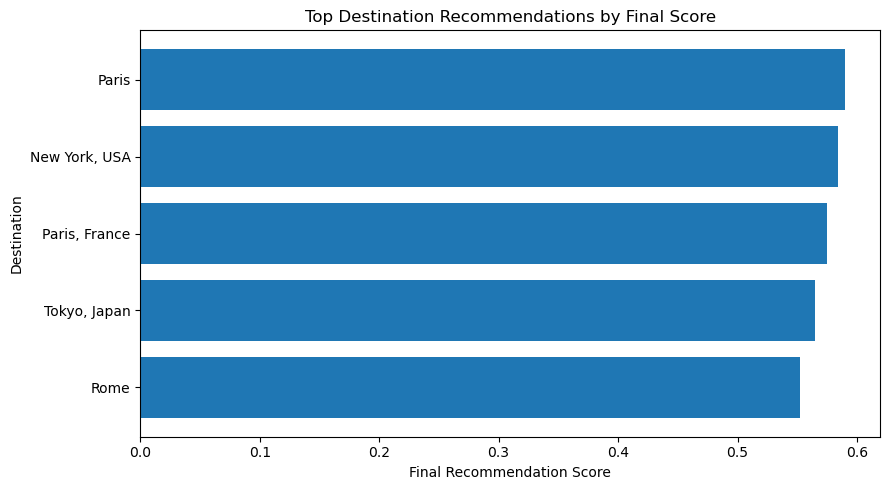

In [16]:

# ============================================================
# VISUALIZE RECOMMENDATION SCORES
# ============================================================

plot_data = sample_recommendations.sort_values("final_score", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_data["destination"], plot_data["final_score"])
plt.title("Top Destination Recommendations by Final Score")
plt.xlabel("Final Recommendation Score")
plt.ylabel("Destination")
plt.tight_layout()
plt.show()



# 7. Evaluation

Because the dataset does not contain user ratings or satisfaction labels, RMSE is not the right evaluation metric. Instead, this project evaluates recommendations using practical proxy metrics:

- Average final score
- Average profile similarity
- Average budget fit
- Average duration fit
- Average preference match
- Diversity of countries, accommodations, and transportation types


In [17]:
# ============================================================
# EVALUATION FUNCTIONS
# ============================================================

def evaluate_recommendations(recommendation_df, full_catalog):
    metrics = {
        "n_recommendations": len(recommendation_df),
        "coverage_at_k": recommendation_df["destination"].nunique() / full_catalog["destination"].nunique(),
        "country_diversity": recommendation_df["destination_country"].nunique(),
        "accommodation_diversity": recommendation_df["common_accommodation"].nunique(),
        "transportation_diversity": recommendation_df["common_transportation"].nunique(),
        "avg_final_score": recommendation_df["final_score"].mean(),
        "avg_profile_similarity": recommendation_df["profile_similarity"].mean(),
        "avg_budget_fit": recommendation_df["budget_fit"].mean(),
        "avg_duration_fit": recommendation_df["duration_fit"].mean(),
        "avg_preference_match": recommendation_df["preference_match"].mean(),
        "avg_popularity_score": recommendation_df["popularity_score"].mean()
    }

    return pd.DataFrame([metrics])


sample_eval = evaluate_recommendations(sample_recommendations, destination_profiles)
display(sample_eval)


,n_recommendations,coverage_at_k,country_diversity,accommodation_diversity,transportation_diversity,avg_final_score,avg_profile_similarity,avg_budget_fit,avg_duration_fit,avg_preference_match,avg_popularity_score
0,5,0.083333,4,1,3,0.573358,0.112501,0.817895,0.946429,0.6,0.828571



## Evaluation Interpretation

The evaluation table summarizes the quality of the recommendation list.

- A higher average final score means stronger overall fit.
- A higher budget fit means the destinations are more realistic for the user's budget.
- A higher duration fit means the destinations better match the desired trip length.
- Diversity metrics show whether the system recommends varied options or repetitive destinations.

These are proxy metrics because there are no actual user ratings in the dataset.


In [18]:
# ============================================================
# QA TESTING ACROSS MULTIPLE TRAVELER PERSONAS
# ============================================================

test_profiles = [
    {
        "profile_name": "Budget Short Trip Traveler",
        "age": 23,
        "gender": "Male",
        "nationality": "American",
        "accommodation_type": "Hostel",
        "transportation_type": "Train",
        "duration_days": 3,
        "total_budget": 600,
        "season": "Spring",
        "preferred_country": "Any"
    },
    {
        "profile_name": "Comfort International Traveler",
        "age": 35,
        "gender": "Female",
        "nationality": "Filipino",
        "accommodation_type": "Hotel",
        "transportation_type": "Flight",
        "duration_days": 7,
        "total_budget": 2000,
        "season": "Summer",
        "preferred_country": "Any"
    },
    {
        "profile_name": "Long Vacation Traveler",
        "age": 45,
        "gender": "Male",
        "nationality": "Canadian",
        "accommodation_type": "Resort",
        "transportation_type": "Flight",
        "duration_days": 12,
        "total_budget": 3500,
        "season": "Winter",
        "preferred_country": "Any"
    }
]

qa_results = []

for profile in test_profiles:
    recs = recommend_getaways(
        age=profile["age"],
        gender=profile["gender"],
        nationality=profile["nationality"],
        accommodation_type=profile["accommodation_type"],
        transportation_type=profile["transportation_type"],
        duration_days=profile["duration_days"],
        total_budget=profile["total_budget"],
        season=profile["season"],
        preferred_country=profile["preferred_country"],
        top_n=5
    )

    eval_df = evaluate_recommendations(recs, destination_profiles)
    eval_df.insert(0, "profile_name", profile["profile_name"])
    qa_results.append(eval_df)

qa_results_df = pd.concat(qa_results, ignore_index=True)
display(qa_results_df)


,profile_name,n_recommendations,coverage_at_k,country_diversity,accommodation_diversity,transportation_diversity,avg_final_score,avg_profile_similarity,avg_budget_fit,avg_duration_fit,avg_preference_match,avg_popularity_score
0,Budget Short Trip Traveler,5,0.083333,2,2,3,0.448871,0.242588,0.721429,0.413095,0.466667,0.400000
1,Comfort International Traveler,5,0.083333,4,2,2,0.587807,0.144357,0.852294,0.901984,0.733333,0.714286
2,Long Vacation Traveler,5,0.083333,4,2,2,0.464303,0.146466,0.783810,0.650000,0.466667,0.371429



## QA Testing Interpretation

The QA test checks if the recommender adapts to different traveler personas. A good recommender should not return the exact same destinations for all travelers.

If the average budget fit, duration fit, and preference match remain reasonable across different profiles, this suggests that WanderWise is adjusting its rankings based on user inputs.

If outputs become too similar across users, a future improvement would be to reduce the popularity weight or add more personalized features.



# 9. Streamlit App

For a more impressive demo, we have created the

```text
wanderwise_streamlit_app.py
```

To run it:

```bash
streamlit run wanderwise_streamlit_app.py
```

Make sure `Travel details dataset.csv` is in the same folder as the Streamlit app.



# 10. Final Discussion

## Strengths

WanderWise is stronger than a simple popularity-based recommender because it uses multiple travel decision factors. It considers traveler profile, budget, duration, accommodation, transportation, and historical destination popularity.

The system is also interpretable because each output includes score components and recommendation comments.

## Limitations

The dataset does not contain explicit ratings, clicks, bookings, or satisfaction outcomes. Because of this, the model cannot directly validate whether a traveler liked the recommendation. The dataset is also relatively small, so outputs may be sensitive to limited historical examples.

## Future Improvements

Future versions can include:

- User satisfaction ratings
- Destination attraction data
- Weather and seasonality data
- Collaborative filtering if user-item interaction data becomes available
- Diversity-aware ranking
- Streamlit deployment

## Conclusion

WanderWise demonstrates how a hybrid recommender system can be built using traveler demographics and trip history. The project includes data cleaning, EDA, feature engineering, model development, evaluation, interpretation, and a classroom-ready demo app.
